<a href="https://colab.research.google.com/github/rahiakela/small-language-models-fine-tuning/blob/main/build-and-fine-tune-small-language-model/01_build_GPT_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Chapter 2 Building a small GPT from Scratch


Based on the video demo by Andrej Karpathy on YOUTUBE: https://www.youtube.com/watch?v=kCc8FmEb1nY

Added more comments, explainations, and additial functions

## Part 1: The Big Picture

**What is a Language Model?**

A language model is simply a program that predicts the next word (or character) in a sequence. Given
“The cat sat on the”, it should predict “mat” (or something sensible, like “floor” or “sofa”).

**How it learns:**
1. Read lots of text
2. Try to predict each next character
3. Get feedback on mistakes
4. Adjust internal “weights” to do better
5. Repeat millions of times

That’s it. Everything else is optimization to make this work better.

(A detailed video demonstration by Andrej Karpathy is available at https://youtu.be/kCc8FmEb1nY,
the following simple codes are derived from this demo)

## Part 2: Setting Up Your Workspace

Please connect to a free T4 GPU:   go to top right corner and click connect and Change runtime type

### Step 1: Open Google Colab

1. Go to **Runtime → Change runtime type**
2. Select **"T4 GPU"**
3. Click **Save**

### Step 2: Download Shakespeare Dataset

We'll train on Shakespeare's works---about 1MB of text, perfect for learning.

In [1]:
# We always start with a dataset to train on. Let's download the tiny shakespeare dataset
!wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt

--2026-07-06 06:27:33--  https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1115394 (1.1M) [text/plain]
Saving to: ‘input.txt’

input.txt           100%[===================>]   1.06M  --.-KB/s    in 0.03s   

2026-07-06 06:27:33 (33.4 MB/s) - ‘input.txt’ saved [1115394/1115394]



In [2]:
# read it in to inspect it
with open('/content/input.txt', 'r', encoding='utf-8') as f:
    text = f.read()
print("length of dataset in characters: ", len(text))

# let's look at the first 1000 characters
print(text[:500])

length of dataset in characters:  1115394
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


In [3]:
# here are all the unique characters that occur in this text
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(''.join(chars))
print(vocab_size)


 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
65


## Part 3: Tokenization - Converting Text to Numbers

Computers don't understand text---they work with numbers. We need to convert characters to integers.

### Building Our Vocabulary

In [4]:
# Get all unique characters in our dataset
chars = sorted(list(set(text)))
vocab_size = len(chars)

print(f"Vocabulary size: {vocab_size}")
print(f"All characters: {''.join(chars)}")


Vocabulary size: 65
All characters: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz



### Creating Encoder and Decoder

In [5]:
# Create mappings
char_to_idx = {ch: i for i, ch in enumerate(chars)}  # char to integer
idx_to_char = {i: ch for i, ch in enumerate(chars)}  # integer to char

# Encoder: text → numbers
encode = lambda s: [char_to_idx[c] for c in s]

# Decoder: numbers → text
decode = lambda l: ''.join([idx_to_char[i] for i in l])

# Test it
encoded = encode("Hello")
print(f"'Hello' encoded: {encoded}")
print(f"Decoded back: '{decode(encoded)}'")

'Hello' encoded: [20, 43, 50, 50, 53]
Decoded back: 'Hello'


### Encoding the Entire Dataset

In [6]:
# let's now encode the entire text dataset and store it into a torch.Tensor
import torch

# Encode all text and convert to PyTorch tensor
data = torch.tensor(encode(text), dtype=torch.long)

print(f"Data shape: {data.shape}")
print(f"First 100 encoded characters: {data[:500]}")

Data shape: torch.Size([1115394])
First 100 encoded characters: tensor([18, 47, 56, 57, 58,  1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 14, 43, 44,
        53, 56, 43,  1, 61, 43,  1, 54, 56, 53, 41, 43, 43, 42,  1, 39, 52, 63,
         1, 44, 59, 56, 58, 46, 43, 56,  6,  1, 46, 43, 39, 56,  1, 51, 43,  1,
        57, 54, 43, 39, 49,  8,  0,  0, 13, 50, 50, 10,  0, 31, 54, 43, 39, 49,
         6,  1, 57, 54, 43, 39, 49,  8,  0,  0, 18, 47, 56, 57, 58,  1, 15, 47,
        58, 47, 64, 43, 52, 10,  0, 37, 53, 59,  1, 39, 56, 43,  1, 39, 50, 50,
         1, 56, 43, 57, 53, 50, 60, 43, 42,  1, 56, 39, 58, 46, 43, 56,  1, 58,
        53,  1, 42, 47, 43,  1, 58, 46, 39, 52,  1, 58, 53,  1, 44, 39, 51, 47,
        57, 46, 12,  0,  0, 13, 50, 50, 10,  0, 30, 43, 57, 53, 50, 60, 43, 42,
         8,  1, 56, 43, 57, 53, 50, 60, 43, 42,  8,  0,  0, 18, 47, 56, 57, 58,
         1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 18, 47, 56, 57, 58,  6,  1, 63,
        53, 59,  1, 49, 52, 53, 61,  1, 15, 39, 47, 59, 

## Part 4: Train/Validation Split

Never test on your training data! Split into training (90%) and validation (10%) sets.


In [7]:
# Let's now split up the data into train and validation sets
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

print(f"Training examples: {len(train_data):,}")
print(f"Validation examples: {len(val_data):,}")

Training examples: 1,003,854
Validation examples: 111,540


## Part 5: Understanding Context Windows

A language model doesn't see infinite history---just a fixed **context window** (block size).

In [8]:
block_size = 8  # Maximum context length

# Example: show training examples
x = train_data[:block_size]
y = train_data[1:block_size + 1]

print("Training examples with context:")
for t in range(block_size):
    context = x[:t+1]
    target = y[t]
    print(f"Context: {decode(context.tolist())!r:20} → Target: {decode([target.item()])!r}")

Training examples with context:
Context: 'F'                  → Target: 'i'
Context: 'Fi'                 → Target: 'r'
Context: 'Fir'                → Target: 's'
Context: 'Firs'               → Target: 't'
Context: 'First'              → Target: ' '
Context: 'First '             → Target: 'C'
Context: 'First C'            → Target: 'i'
Context: 'First Ci'           → Target: 't'


## Part 6: Batching for Efficiency
Process multiple sequences in parallel for speed.

In [9]:
torch.manual_seed(1337) # Random number

batch_size = 4 # how many independent sequences will we process in parallel?
#A larger batch size means more samples are processed simultaneously, which can help with faster training and provide more stable gradient estimates, but requires more memory.

block_size = 8 # what is the maximum context length for predictions?
#The model will consider only the most recent block_size tokens as the context for generating the next token prediction.
#For example, if block_size = 8, each sequence in the batch will have a context window of 8 tokens, allowing the model to “see” up to 8 tokens at a time. This limits the amount of text the model considers, which can be useful for controlling memory use and focusing the model on recent context when predicting the next token.

def get_batch(split):
    """Generate a batch of training data"""
    data = train_data if split == 'train' else val_data

    # Pick random starting positions
    ix = torch.randint(len(data) - block_size, (batch_size,))

    # Stack sequences into batches
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])

    return x, y

# Get a batch
xb, yb = get_batch('train')

print(f"Input batch shape: {xb.shape}")  # (batch_size, block_size)
print(f"Target batch shape: {yb.shape}")
print(f"\nFirst sequence in batch:")
print(f"Input: {decode(xb[0].tolist())!r}")
print(f"Target: {decode(yb[0].tolist())!r}")

Input batch shape: torch.Size([4, 8])
Target batch shape: torch.Size([4, 8])

First sequence in batch:
Input: "Let's he"
Target: "et's hea"


## Part 7: A Simple Baseline - The Bigram Model

Before building the full transformer, let's start with the simplest possible model: predict the next character based on *only* the current character (ignoring all context).
We are using PyTorch’s neural network module (nn.Module).

In [10]:
import torch.nn as nn
from torch.nn import functional as F

class BigramLanguageModel(nn.Module):
    """Simplest possible language model"""

    def __init__(self, vocab_size):
        super().__init__()
        # Each token predicts logits for next token
        self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)

    def forward(self, idx, targets=None):
        # idx: (B, T) tensor of token indices
        # logits: (B, T, C) tensor of predictions
        logits = self.token_embedding_table(idx)

        if targets is None:
            loss = None
        else:
            # Reshape for cross-entropy loss
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens):
        """Generate new tokens"""
        for _ in range(max_new_tokens):
            # Get predictions
            logits, _ = self(idx)
            # Focus on last time step
            logits = logits[:, -1, :]  # (B, C)
            # Convert to probabilities
            probs = F.softmax(logits, dim=-1)
            # Sample from distribution
            idx_next = torch.multinomial(probs, num_samples=1)
            # Append to sequence
            idx = torch.cat((idx, idx_next), dim=1)

        return idx

In [11]:
# Create model
model = BigramLanguageModel(vocab_size)
logits, loss = model(xb, yb)

print(f"Logits shape: {logits.shape}")
print(f"Initial loss: {loss.item():.4f}")
print(f"Expected loss: {-torch.log(torch.tensor(1.0/vocab_size)):.4f}")

Logits shape: torch.Size([32, 65])
Initial loss: 5.0364
Expected loss: 4.1744


### Generate Before Training

In [12]:
# Generate 100 characters from untrained model
context = torch.zeros((1, 1), dtype=torch.long)
generated = model.generate(context, max_new_tokens=100)
print(decode(generated[0].tolist()))


lfJeukRuaRJKXAYtXzfJ:HEPiu--sDioi;ILCo3pHNTmDwJsfheKRxZCFs
lZJ XQc?:s:HEzEnXalEPklcPU cL'DpdLCafBheH


As you can see they are meaningless.

## Part 8: Training the Bigram Model

In [13]:
# Setup optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

# Training loop
batch_size = 32

for steps in range(10000):
    # Get batch
    xb, yb = get_batch('train')

    # Forward pass
    logits, loss = model(xb, yb)

    # Backward pass
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    # Print progress
    if steps % 1000 == 0:
        print(f"Step {steps}: loss = {loss.item():.4f}")

print(f"\nFinal loss: {loss.item():.4f}")

Step 0: loss = 4.6477
Step 1000: loss = 3.6650
Step 2000: loss = 3.3166
Step 3000: loss = 2.8780
Step 4000: loss = 2.6928
Step 5000: loss = 2.4840
Step 6000: loss = 2.5045
Step 7000: loss = 2.5102
Step 8000: loss = 2.4093
Step 9000: loss = 2.4303

Final loss: 2.3624


### Generate After Training

In [14]:
context = torch.zeros((1, 1), dtype=torch.long)
generated = model.generate(context, max_new_tokens=500)
print(decode(generated[0].tolist()))


M:
IUSh t,
F th he d ke alved.
Thupld, cipbll t
I: ir w, l me sie hend lor ito'l an e

I:
Gochosen ea ar btamandd halind
Aust, plt t wadyotl
I bel qunganonoth he m he de avellis k'l, tond soran:

WI he toust are bot g e n t s d je hid t his IAces I my ig t
Ril'swoll e pupat inouleacends-athiqu heamer te
Wht s

MI wect!-lltherotheve t fe;
WAnd py;

PO t s ld tathat, ir V
IO thesecin teot tit ado ilorer.
Ply, d'stacoes, ld omat mealellly yererer EMEvesas ie IZEd pave mautoofareanerllleyomerer but?


**Why is it bad?** The bigram model has **no memory**---each prediction only sees one character. "Th" should predict "e", but our model doesn't see the "T"!

## Part 9: The Mathematical Trick - Self-Attention
We need characters to "talk to each other." This is **self-attention**.

### Concept: Weighted Averages

Before attention, let's understand weighted averages with a simple trick:

In [ ]:
# toy example illustrating how matrix multiplication can be used for a "weighted aggregation"
torch.manual_seed(42)
B, T, C = 4, 8, 2  # Batch, Time, Channels
x = torch.randn(B, T, C)

# We want: x[b,t] = average of x[b, 0:t+1]
# Inefficient way (loops):
xbow = torch.zeros((B, T, C))
for b in range(B):
    for t in range(T):
        xprev = x[b, :t+1]  # All previous tokens
        xbow[b, t] = torch.mean(xprev, dim=0)

print("Using loops:")
print(xbow[0])  # First batch element

Using loops:
tensor([[ 1.9269,  1.4873],
        [ 1.4138, -0.3091],
        [ 1.1687, -0.6176],
        [ 0.8657, -0.8644],
        [ 0.5422, -0.3617],
        [ 0.3864, -0.5354],
        [ 0.2272, -0.5388],
        [ 0.1027, -0.3762]])



**Efficient way using matrix multiplication:**

In [ ]:

# Create lower triangular matrix
wei = torch.tril(torch.ones(T, T))
wei = wei / wei.sum(1, keepdim=True)  # Normalize rows

print("Weight matrix:")
print(wei)

# Matrix multiply
xbow2 = wei @ x  # (T, T) @ (B, T, C) → (B, T, C)

print("\nUsing matrix multiply:")
print(xbow2[0])

# Check they're the same
print(f"\nAre they equal? {torch.allclose(xbow, xbow2)}")

Weight matrix:
tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3333, 0.3333, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2500, 0.2500, 0.2500, 0.2500, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2000, 0.2000, 0.2000, 0.2000, 0.2000, 0.0000, 0.0000, 0.0000],
        [0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.0000, 0.0000],
        [0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.0000],
        [0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250]])

Using matrix multiply:
tensor([[ 1.9269,  1.4873],
        [ 1.4138, -0.3091],
        [ 1.1687, -0.6176],
        [ 0.8657, -0.8644],
        [ 0.5422, -0.3617],
        [ 0.3864, -0.5354],
        [ 0.2272, -0.5388],
        [ 0.1027, -0.3762]])

Are they equal? True


**Key insight**: Matrix multiplication can compute weighted averages in parallel!


### Using Softmax for Data-Dependent Weights

In [ ]:
# Version 3: Use softmax
tril = torch.tril(torch.ones(T, T))
wei = torch.zeros((T, T))
wei = wei.masked_fill(tril == 0, float('-inf'))  # Mask future
wei = F.softmax(wei, dim=-1)  # Normalize
xbow3 = wei @ x

print(torch.allclose(xbow, xbow3))  # True


True


## Part 10: Implementing Self-Attention
Now the magic: make weights **data-dependent**!

In [ ]:
torch.manual_seed(1337)
B, T, C = 4, 8, 32  # Bigger embedding dimension
x = torch.randn(B, T, C)

# Single Head of Self-Attention
head_size = 16

# Create Query, Key, Value projections
key = nn.Linear(C, head_size, bias=False)
query = nn.Linear(C, head_size, bias=False)
value = nn.Linear(C, head_size, bias=False)

k = key(x)    # (B, T, 16)
q = query(x)  # (B, T, 16)
v = value(x)  # (B, T, 16)

# Compute attention scores ("affinities")
wei = q @ k.transpose(-2, -1)  # (B, T, T)

# Scale by sqrt(head_size) for stable gradients
wei = wei * (head_size ** -0.5)

# Mask future tokens (for autoregressive generation)
tril = torch.tril(torch.ones(T, T))
wei = wei.masked_fill(tril == 0, float('-inf'))

# Softmax to get attention weights
wei = F.softmax(wei, dim=-1)

# Weighted aggregation of values
out = wei @ v  # (B, T, 16)

print(f"Output shape: {out.shape}")
print(f"\nAttention weights for first token:")
print(wei[0, 0])  # Should be [1, 0, 0, ..., 0]
print(f"\nAttention weights for last token:")
print(wei[0, -1])  # Attends to all previous tokens


Output shape: torch.Size([4, 8, 16])

Attention weights for first token:
tensor([1., 0., 0., 0., 0., 0., 0., 0.], grad_fn=<SelectBackward0>)

Attention weights for last token:
tensor([0.0845, 0.1197, 0.1078, 0.1537, 0.1086, 0.1146, 0.1558, 0.1553],
       grad_fn=<SelectBackward0>)



## Part 11: Building a Complete Transformer Block

### Multi-Head Attention

In [ ]:
class Head(nn.Module):
    """One head of self-attention"""

    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)
        q = self.query(x)
        v = self.value(x)

        # Compute attention
        wei = q @ k.transpose(-2, -1) * (C ** -0.5)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)

        # Weighted aggregation
        out = wei @ v
        return out

class MultiHeadAttention(nn.Module):
    """Multiple attention heads in parallel"""

    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # Run all heads in parallel and concatenate
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

Dr. Liu's notes:
- Attention is a **communication mechanism**. Can be seen as nodes in a directed graph looking at each other and aggregating information with a weighted sum from all nodes that point to them, with data-dependent weights.
- There is no notion of space. Attention simply acts over a set of vectors. This is why we need to positionally encode tokens.
- Each example across batch dimension is of course processed completely independently and never "talk" to each other
- In an "encoder" attention block just delete the single line that does masking with `tril`, allowing all tokens to communicate. This block here is called a "decoder" attention block because it has triangular masking, and is usually used in autoregressive settings, like language modeling.
- "self-attention" just means that the keys and values are produced from the same source as queries. In "cross-attention", the queries still get produced from x, but the keys and values come from some other, external source (e.g. an encoder module)
- "Scaled" attention additional divides `wei` by 1/sqrt(head_size). This makes it so when input Q,K are unit variance, wei will be unit variance too and Softmax will stay diffuse and not saturate too much. Illustration below

        Input Sequence: ["The", "cat", "sat", "on", "the", "mat"]
                              |
                              v
                        Embedding Layer
                              |
                              v
                     Self-Attention Mechanism
                           ┌───────────┐
                           │           │
                           │ Multi-Head│
                           │ Attention │
                           │           │
                           └───────────┘
                             /    |    \
                            /     |     \
                           v      v      v
                     "The"   "cat"   "sat"  ... (tokens in the sequence)

1. **Input Tokens**: The words "The", "cat", "sat", etc., are input to the model.
2. **Embedding Layer**: Each word is converted into an embedding vector representing its meaning.
3. **Self-Attention Mechanism**:
   - Each token is assigned three vectors: **Query (Q)**, **Key (K)**, and **Value (V)**.
   - The model calculates the **attention score** between tokens by computing the dot product of the Query of one token with the Key of another.
   - A **softmax** function is applied to these scores, turning them into weights.
   - These weights are used to scale the Value vectors, which represent the "meaning" of each token in context.
4. **Multi-Head Attention**: The process is repeated across multiple attention heads. Each head learns different aspects of the relationships between tokens (e.g., one head might focus on syntactic roles, while another might capture semantic relationships).
5. **Output Representation**: The weighted sum of the Value vectors from each head is combined to form the final output representation for each token, enriched with context.

In essence, self-attention lets each token “attend” to others, capturing dependencies in the input, even over long distances. This mechanism is foundational for the **transformer architecture**, enabling models like GPT to understand context and generate coherent text.


### Feed-Forward Network

In [ ]:
class FeedForward(nn.Module):
    """Simple feed-forward network"""

    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),  # Expand
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),  # Project back
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

### Transformer Block

In [ ]:
class Block(nn.Module):
    """Transformer block: attention + feed-forward"""

    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedForward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        # Residual connections + layer norm
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x-0.5

## Part 12: The Complete GPT Model

In [ ]:
class GPTLanguageModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head=n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        # Embeddings
        tok_emb = self.token_embedding_table(idx)  # (B, T, C)
        pos_emb = self.position_embedding_table(torch.arange(T, device=idx.device))  # (T, C)
        x = tok_emb + pos_emb  # (B, T, C)

        # Transformer blocks
        x = self.blocks(x)
        x = self.ln_f(x)

        # Output projection
        logits = self.lm_head(x)  # (B, T, vocab_size)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            # Crop context to block_size
            idx_cond = idx[:, -block_size:]
            # Get predictions
            logits, _ = self(idx_cond)
            # Focus on last time step
            logits = logits[:, -1, :]
            # Sample
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            # Append
            idx = torch.cat((idx, idx_next), dim=1)

        return idx

## Part 13: Training the Full Model

In [ ]:
# Hyperparameters
batch_size = 16 # how many independent sequences will we process in parallel?
block_size = 32 # what is the maximum context length for predictions?
max_iters = 5000
eval_interval = 100
learning_rate = 1e-3
device = 'cuda' if torch.cuda.is_available() else 'cpu'
eval_iters = 200
n_embd = 64
n_head = 4
n_layer = 4
dropout = 0.0
dropout = 0.2

# Create model
model = GPTLanguageModel()
model = model.to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters())/1e6:.2f}M")

# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

# data loading (ensure this is defined before the training loop if it wasn't)
def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    # Explicitly move tensors to the correct device
    x, y = x.to(device), y.to(device)
    return x, y

# Training loop
train_losses = []   #newly added
val_losses = []   #newly added
for iter in range(max_iters):

    # every once in a while evaluate the loss on train and val sets
    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss()
        train_losses.append(losses['train']) #newly added
        val_losses.append(losses['val'])   #newly added
        print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    # Get batch
    xb, yb = get_batch('train')

    # Forward & backward
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

# Generate
context = torch.zeros((1, 1), dtype=torch.long, device=device)
print(decode(model.generate(context, max_new_tokens=500)[0].tolist()))

Parameters: 0.21M
step 0: train loss 4.3310, val loss 4.3286
step 100: train loss 2.6967, val loss 2.6999
step 200: train loss 2.5407, val loss 2.5251
step 300: train loss 2.4689, val loss 2.4698
step 400: train loss 2.4059, val loss 2.4125
step 500: train loss 2.3599, val loss 2.3795
step 600: train loss 2.3188, val loss 2.3305
step 700: train loss 2.2875, val loss 2.2966
step 800: train loss 2.2489, val loss 2.2712
step 900: train loss 2.2184, val loss 2.2353
step 1000: train loss 2.1936, val loss 2.2073
step 1100: train loss 2.1677, val loss 2.1893
step 1200: train loss 2.1309, val loss 2.1547
step 1300: train loss 2.1099, val loss 2.1340
step 1400: train loss 2.0815, val loss 2.1191
step 1500: train loss 2.0634, val loss 2.1126
step 1600: train loss 2.0487, val loss 2.0820
step 1700: train loss 2.0303, val loss 2.0803
step 1800: train loss 2.0232, val loss 2.0715
step 1900: train loss 2.0121, val loss 2.0642
step 2000: train loss 1.9890, val loss 2.0400
step 2100: train loss 1.9746

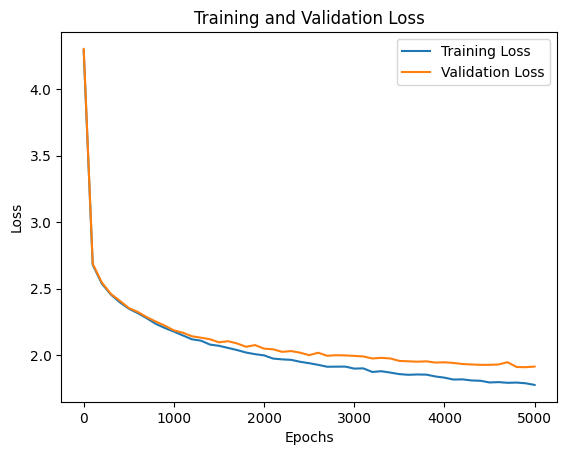

In [ ]:
# Plot training loss vs. epochs
import matplotlib.pyplot as plt
plt.plot(range(0, max_iters + 1, eval_interval), train_losses, label='Training Loss')
plt.plot(range(0, max_iters + 1, eval_interval), val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

###** Full finished code, for reference**

You may want to refer directly to the git repo instead though.

In [ ]:
import torch
import torch.nn as nn
from torch.nn import functional as F

# hyperparameters
batch_size = 16  #16
# how many independent sequences will we process in parallel?
#Specifies the number of sequences processed simultaneously in each batch.
#Increasing batch_size allows more data to be processed in parallel, which can stabilize training and potentially reduce training time. However, larger batches require more memory, especially on a GPU.
#Typical values can range from 8 to 64, depending on memory availability.

block_size = 32 #64 #32 # what is the maximum context length for predictions?
#Determines the maximum context length for predictions, i.e., the number of tokens considered in each input sequence.
#A larger block_size enables the model to consider a broader context when predicting, but also increases memory usage. For smaller datasets or shorter dependencies, a smaller value (like 32) may suffice. For long-range dependencies, increasing it to values like 128 or 256 can improve accuracy, given sufficient computational resources.

max_iters = 1000
#The total number of training iterations. This defines how long the model will train.
#Lower values might result in underfitting, while excessive values can lead to overfitting, especially if not paired with a validation-based stopping criterion.

eval_interval = 100   #The interval (in iterations) at which model performance is evaluated on validation data.

learning_rate = 1e-3
#Specifies the rate at which the model learns by updating weights. This parameter is crucial for training stability.
#Lower values (e.g., 1e-4) offer slower but more stable learning, especially useful for fine-tuning or sensitive models. Higher values (e.g., 1e-2) can speed up learning but may cause instability, particularly for complex models.

device = 'cuda' if torch.cuda.is_available() else 'cpu'
eval_iters = 400 #200
#Number of batches used to estimate validation loss.
#Higher values improve accuracy of the loss estimate but add computational overhead. If set too low, validation loss estimates may be noisy.

n_embd = 64 #128 #64
#Embedding dimension that defines the dimensionality of each token's representation.
#Smaller values (e.g., 64) reduce model capacity and training time but may limit the model's ability to capture intricate relationships. Higher values (e.g., 256) increase capacity but demand more memory and computational power.

n_head = 8 #8
#Specifies the number of attention heads in each layer. Multi-head attention allows the model to focus on different parts of the sequence simultaneously.
#Lower values (e.g., 4) may reduce model performance on tasks requiring diverse dependencies, while higher values (e.g., 16) allow for more comprehensive attention patterns at the cost of additional memory.

n_layer = 8 #8
#Number of Transformer layers (blocks) in the model. Each block adds complexity and depth, allowing the model to capture more nuanced patterns.
#Reducing the number of layers (e.g., 4) can help if resources are limited or for simpler datasets. More layers (e.g., 12 or 24) improve the model’s representational capacity but increase memory requirements and training time.

dropout = 0.0
#Dropout is a regularization technique that randomly “drops out” units during training to prevent overfitting.
#Setting dropout to 0.1 or 0.2 can improve generalization by forcing the model to learn more robust representations. In this code, dropout=0.0 suggests no dropout is applied, which may work well if overfitting is not a concern but can lead to overfitting on smaller datasets.

# ------------

torch.manual_seed(1337)
#The line torch.manual_seed(1337) sets the random seed for generating random numbers in PyTorch to ensure reproducibility. Here’s a breakdown of what this means and why it’s useful:
#Reproducibility: Setting a fixed seed (like 1337 here) allows the same sequence of random numbers to be generated each time the code runs. This is particularly important for tasks involving randomness, such as initialization of model weights, shuffling of data, or sampling during training, as it ensures that results are consistent and experiments are repeatable.
#Choice of Seed: The specific number (1337 in this case) is arbitrary; any integer can be used. However, it’s common practice to choose an easy-to-remember or significant number as the seed.
#Without setting a manual seed, running the same code multiple times could yield slightly different results each time due to the randomness in initializations and data shuffling.


!wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

# here are all the unique characters that occur in this text
chars = sorted(list(set(text)))
vocab_size = len(chars)
# create a mapping from characters to integers
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s] # encoder: take a string, output a list of integers
decode = lambda l: ''.join([itos[i] for i in l]) # decoder: take a list of integers, output a string

# Train and test splits
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9*len(data)) # first 90% will be train, rest val
train_data = data[:n]
val_data = data[n:]

# data loading
def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

class Head(nn.Module):
    """ one head of self-attention """

    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B,T,C = x.shape
        #B is the batch size, T is the sequence length (number of tokens), and C is the embedding dimension.
        #This line unpacks the shape of the input tensor x, which has the shape (B, T, C).

        k = self.key(x)   # (B,T,C)
        q = self.query(x) # (B,T,C)
        # compute attention scores ("affinities")
        #These lines project x into key (k) and query (q) representations using learned linear transformations.
        #Each key, query, and value representation captures different aspects of the information in x for calculating attention.
        #After transformation, k and q still have the shape (B, T, C).

        wei = q @ k.transpose(-2,-1) * C**-0.5 # (B, T, C) @ (B, C, T) -> (B, T, T)
        #The @ operator performs matrix multiplication between q and the transpose of k.
        #k.transpose(-2, -1) changes the shape of k to (B, C, T), so q @ k.transpose(-2, -1) produces a matrix of shape (B, T, T).
        #This operation calculates the raw attention scores, indicating the relationship between each query and key pair. These scores are scaled by C**-0.5 to prevent overly large values, which helps stabilize gradients during training.

        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf')) # (B, T, T)
        #This line applies a mask to the wei matrix using a lower triangular matrix (tril) to enforce causality.
        #The masking sets upper-triangular values in wei to -inf, meaning only past and current tokens are attended to, not future ones. This ensures that predictions for each token only depend on past tokens in the sequence.

        wei = F.softmax(wei, dim=-1) # (B, T, T)
        #The softmax function normalizes the attention scores wei along the last dimension (sequence length), turning them into a probability distribution that sums to 1.
        #This distribution represents how much attention each token in the sequence should pay to other tokens.
        wei = self.dropout(wei)
        # perform the weighted aggregation of the values
        #Applies dropout to wei to prevent overfitting by randomly setting a fraction of the attention probabilities to zero during training, helping improve generalization.

        v = self.value(x) # (B,T,C)
        #The input x is projected to obtain the values v using another linear transformation.
        # v has the shape (B, T, C), holding information from x to be aggregated based on the attention scores.
        out = wei @ v # (B, T, T) @ (B, T, C) -> (B, T, C)
        #This line performs the weighted sum of the values v, using the attention weights in wei.
        #The matrix multiplication wei @ v yields an output of shape (B, T, C), where each token’s representation in the sequence is adjusted based on its attention to other tokens.
        return out

class MultiHeadAttention(nn.Module):
    """ multiple heads of self-attention in parallel """

    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

class FeedFoward(nn.Module):
    """ a simple linear layer followed by a non-linearity """

    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    """ Transformer block: communication followed by computation """

    def __init__(self, n_embd, n_head):
        # n_embd: embedding dimension, n_head: the number of heads we'd like
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedFoward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

# super simple bigram model
#The BigramLanguageModel class is a simple language model that generates text one token at a time, based on bigrams (considering two tokens at a time for predictions).
class BigramLanguageModel(nn.Module):

    def __init__(self):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        #creates an embedding layer that maps each token in the vocabulary to a vector of size n_embd, effectively learning representations for each token.

        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        #adds position embeddings, allowing the model to incorporate positional information for each token up to block_size.

        self.blocks = nn.Sequential(*[Block(n_embd, n_head=n_head) for _ in range(n_layer)])
        # is a sequence of Transformer blocks (Block instances), which apply multi-head attention and feedforward layers to create a context-aware representation for each token.

        self.ln_f = nn.LayerNorm(n_embd) #  a final layer normalization to stabilize training.
        self.lm_head = nn.Linear(n_embd, vocab_size)
        # projects the final token representations back to the vocabulary size, outputting logits (unnormalized scores) for each possible next token.

    def forward(self, idx, targets=None):
        B, T = idx.shape
        #Maps the input token indices (idx) to embeddings using token_embedding_table and adds position embeddings from position_embedding_table.
        # idx and targets are both (B,T) tensor of integers
        tok_emb = self.token_embedding_table(idx) # (B,T,C)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device)) # (T,C)
        x = tok_emb + pos_emb # (B,T,C)
        x = self.blocks(x) # (B,T,C)
        x = self.ln_f(x) # (B,T,C)
        logits = self.lm_head(x) # (B,T,vocab_size)
        #Applies a final layer normalization and outputs logits for each token in the vocabulary.
        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    #this function produces new tokens based on the model's predictions in an auto-regressive manner (using previously generated tokens as context).
    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context
        #It samples the next token based on probabilities from the model’s logits for the last generated token and appends it to the sequence until the specified number of tokens (max_new_tokens) are generated.
        for _ in range(max_new_tokens):
            # crop idx to the last block_size tokens
            idx_cond = idx[:, -block_size:]
            # get the predictions
            logits, loss = self(idx_cond)
            # focus only on the last time step
            logits = logits[:, -1, :] # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, C)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx

model = BigramLanguageModel()
m = model.to(device)
# print the number of parameters in the model
print(sum(p.numel() for p in m.parameters())/1e6, 'M parameters')

# create a PyTorch optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
#Initializes an AdamW optimizer with weight decay. This optimizer updates the model’s parameters with gradients computed during training.

# Track losses

train_losses = []   #newly added
val_losses = []   #newly added
for iter in range(max_iters):

    # every once in a while evaluate the loss on train and val sets
    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss()
        train_losses.append(losses['train']) #newly added
        val_losses.append(losses['val'])   #newly added
        print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    # sample a batch of data
    xb, yb = get_batch('train')
    #Retrieves a batch of training data (xb, yb) using get_batch, which creates input-target pairs for training.


    # evaluate the loss
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
    #The model performs a forward pass on the batch, computing the loss. optimizer.zero_grad(set_to_none=True) resets the gradients to zero.
    #loss.backward() calculates the gradients, and optimizer.step() updates the model’s parameters based on the gradients.

# generate from the model
context = torch.zeros((1, 1), dtype=torch.long, device=device)
print(decode(m.generate(context, max_new_tokens=2000)[0].tolist()))


--2025-12-22 20:08:38--  https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1115394 (1.1M) [text/plain]
Saving to: ‘input.txt.1’

input.txt.1         100%[===================>]   1.06M  --.-KB/s    in 0.006s  

2025-12-22 20:08:38 (166 MB/s) - ‘input.txt.1’ saved [1115394/1115394]

0.408897 M parameters
step 0: train loss 4.3128, val loss 4.3138
step 100: train loss 2.6295, val loss 2.6355
step 200: train loss 2.4983, val loss 2.5081
step 300: train loss 2.4047, val loss 2.4131
step 400: train loss 2.3321, val loss 2.3441
step 500: train loss 2.2959, val loss 2.3064
step 600: train loss 2.2543, val loss 2.2729
step 700: train loss 2.2127, val loss 2.2361
step 800: train lo

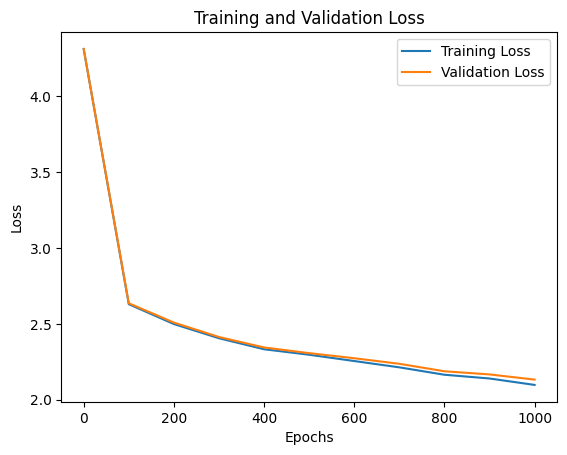

In [ ]:
# Plot training loss vs. epochs
import matplotlib.pyplot as plt
plt.plot(range(0, max_iters + 1, eval_interval), train_losses, label='Training Loss')
plt.plot(range(0, max_iters + 1, eval_interval), val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
# Save the trained model
model_save_path = 'gpt_model.pth'
torch.save(model.state_dict(), model_save_path)
print("Model saved successfully at", model_save_path)

Model saved successfully at gpt_model.pth


On the left side, you can click the Files folder, a model called **gpt_model.pth** has been saved.

## **STOP**

The following shows how you can save and upload your pre-trained model to Hugging Face, you DO NOT have to do these

In [ ]:
!pip install huggingface_hub -U

In [ ]:
from huggingface_hub import login
from google.colab import userdata
#hf_token = userdata.get("smile")
hf_token = userdata.get("HF_TOKEN")
login(token=hf_token, add_to_git_credential=True)


In [ ]:
from huggingface_hub import create_repo

#repo_name = "jpliu168/Bible"  # Replace with your model's name
#create_repo(repo_name, exist_ok=True)

RepoUrl('https://huggingface.co/jpliu168/Bible', endpoint='https://huggingface.co', repo_type='model', repo_id='jpliu168/Bible')

In [ ]:
# Online saving
#model.push_to_hub("jpliu168/Bible", token = hf_token)
#tokenizer.push_to_hub("jpliu168/Bible", token = hf_token)
#processor.push_to_hub("jpliu168/Bible", token = hf_token)
from huggingface_hub import HfApi

# Initialize API client
api = HfApi()

#from huggingface_hub import hf_hub_upload


# Define repository ID and local model file path
repo_id = "jpliu168/Bible"  # Replace with your Hugging Face username and repository name
model_path = "/content/gpt_model.pth"  # Local path to your .pth model file

# Upload model file to the repository
# Upload model file to the repository
api.upload_file(
    path_or_fileobj=model_path,
    path_in_repo="model.pth",
    repo_id=repo_id,
    repo_type="model"  # Specify repository type as "model"
)

gpt_model.pth:   0%|          | 0.00/1.65M [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/jpliu168/Bible/commit/80018d1dff6ead9e6ca970a5730afd5f765aa7bd', commit_message='Upload model.pth with huggingface_hub', commit_description='', oid='80018d1dff6ead9e6ca970a5730afd5f765aa7bd', pr_url=None, repo_url=RepoUrl('https://huggingface.co/jpliu168/Bible', endpoint='https://huggingface.co', repo_type='model', repo_id='jpliu168/Bible'), pr_revision=None, pr_num=None)

In [ ]:

from transformers import AutoModelForVision2Seq, AutoProcessor, AutoTokenizer
#from PIL import Image
import requests
from io import BytesIO

# Load the fine_tuned model and processor
model_path = "jpliu168/Bible"
model = AutoModelForVision2Seq.from_pretrained(model_path, token=hf_token)

processor = AutoProcessor.from_pretrained(model_path, token=hf_token)
tokenizer = AutoTokenizer.from_pretrained(model_path, token=hf_token)



OSError: jpliu168/Bible does not appear to have a file named config.json. Checkout 'https://huggingface.co/jpliu168/Bible/tree/main' for available files.

In [ ]:
# Load the model
model_save_path="/content/gpt_model.pth"
#model_save_path="jpliu168/Bible"
loaded_model = BigramLanguageModel().to(device)
loaded_model.load_state_dict(torch.load(model_save_path))
print("Model loaded successfully")

# Define helper functions
def text_to_token_ids(text, tokenizer):
    return torch.tensor([stoi[c] for c in text], dtype=torch.long).unsqueeze(0)

def token_ids_to_text(token_ids, tokenizer):
    return ''.join([itos[i] for i in token_ids.squeeze().tolist()])

def generate_text_from_input(model, input_text, max_new_tokens=50):
    model.eval()
    context_size = block_size
    encoded = text_to_token_ids(input_text, stoi).to(device)
    with torch.no_grad():
        generated_ids = model.generate(encoded, max_new_tokens=max_new_tokens)
    return token_ids_to_text(generated_ids, itos)

# Test the text generation
input_text = "oh my lord "
print("Generated text:", generate_text_from_input(loaded_model, input_text, max_new_tokens=100))

Model loaded successfully
Generated text: oh my lord s; empant.

CENCARGHLIAWGRRSMBTELAR:
For grond Gramangun t fast the deaut hat has eerdan recther dou


In [ ]:
import torch
import torch.nn as nn
from torch.nn import functional as F

# hyperparameters
batch_size = 32  #16
# how many independent sequences will we process in parallel?
#Specifies the number of sequences processed simultaneously in each batch.
#Increasing batch_size allows more data to be processed in parallel, which can stabilize training and potentially reduce training time. However, larger batches require more memory, especially on a GPU.
#Typical values can range from 8 to 64, depending on memory availability.

block_size = 64 #32 # what is the maximum context length for predictions?
#Determines the maximum context length for predictions, i.e., the number of tokens considered in each input sequence.
#A larger block_size enables the model to consider a broader context when predicting, but also increases memory usage. For smaller datasets or shorter dependencies, a smaller value (like 32) may suffice. For long-range dependencies, increasing it to values like 128 or 256 can improve accuracy, given sufficient computational resources.

max_iters = 30000
#The total number of training iterations. This defines how long the model will train.
#Lower values might result in underfitting, while excessive values can lead to overfitting, especially if not paired with a validation-based stopping criterion.

eval_interval = 100   #The interval (in iterations) at which model performance is evaluated on validation data.

learning_rate = 1e-3
#Specifies the rate at which the model learns by updating weights. This parameter is crucial for training stability.
#Lower values (e.g., 1e-4) offer slower but more stable learning, especially useful for fine-tuning or sensitive models. Higher values (e.g., 1e-2) can speed up learning but may cause instability, particularly for complex models.

device = 'cuda' if torch.cuda.is_available() else 'cpu'
eval_iters = 200 #200
#Number of batches used to estimate validation loss.
#Higher values improve accuracy of the loss estimate but add computational overhead. If set too low, validation loss estimates may be noisy.

n_embd = 128 #64
#Embedding dimension that defines the dimensionality of each token's representation.
#Smaller values (e.g., 64) reduce model capacity and training time but may limit the model's ability to capture intricate relationships. Higher values (e.g., 256) increase capacity but demand more memory and computational power.

n_head = 8 #4
#Specifies the number of attention heads in each layer. Multi-head attention allows the model to focus on different parts of the sequence simultaneously.
#Lower values (e.g., 4) may reduce model performance on tasks requiring diverse dependencies, while higher values (e.g., 16) allow for more comprehensive attention patterns at the cost of additional memory.

n_layer = 8 #4
#Number of Transformer layers (blocks) in the model. Each block adds complexity and depth, allowing the model to capture more nuanced patterns.
#Reducing the number of layers (e.g., 4) can help if resources are limited or for simpler datasets. More layers (e.g., 12 or 24) improve the model’s representational capacity but increase memory requirements and training time.

dropout = 0.0
#Dropout is a regularization technique that randomly “drops out” units during training to prevent overfitting.
#Setting dropout to 0.1 or 0.2 can improve generalization by forcing the model to learn more robust representations. In this code, dropout=0.0 suggests no dropout is applied, which may work well if overfitting is not a concern but can lead to overfitting on smaller datasets.

# ------------

torch.manual_seed(1337)
#The line torch.manual_seed(1337) sets the random seed for generating random numbers in PyTorch to ensure reproducibility. Here’s a breakdown of what this means and why it’s useful:
#Reproducibility: Setting a fixed seed (like 1337 here) allows the same sequence of random numbers to be generated each time the code runs. This is particularly important for tasks involving randomness, such as initialization of model weights, shuffling of data, or sampling during training, as it ensures that results are consistent and experiments are repeatable.
#Choice of Seed: The specific number (1337 in this case) is arbitrary; any integer can be used. However, it’s common practice to choose an easy-to-remember or significant number as the seed.
#Without setting a manual seed, running the same code multiple times could yield slightly different results each time due to the randomness in initializations and data shuffling.


#wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

# here are all the unique characters that occur in this text
chars = sorted(list(set(text)))
vocab_size = len(chars)
# create a mapping from characters to integers
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s] # encoder: take a string, output a list of integers
decode = lambda l: ''.join([itos[i] for i in l]) # decoder: take a list of integers, output a string

# Train and test splits
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9*len(data)) # first 90% will be train, rest val
train_data = data[:n]
val_data = data[n:]

# data loading
def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

class Head(nn.Module):
    """ one head of self-attention """

    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B,T,C = x.shape
        #B is the batch size, T is the sequence length (number of tokens), and C is the embedding dimension.
        #This line unpacks the shape of the input tensor x, which has the shape (B, T, C).

        k = self.key(x)   # (B,T,C)
        q = self.query(x) # (B,T,C)
        # compute attention scores ("affinities")
        #These lines project x into key (k) and query (q) representations using learned linear transformations.
        #Each key, query, and value representation captures different aspects of the information in x for calculating attention.
        #After transformation, k and q still have the shape (B, T, C).

        wei = q @ k.transpose(-2,-1) * C**-0.5 # (B, T, C) @ (B, C, T) -> (B, T, T)
        #The @ operator performs matrix multiplication between q and the transpose of k.
        #k.transpose(-2, -1) changes the shape of k to (B, C, T), so q @ k.transpose(-2, -1) produces a matrix of shape (B, T, T).
        #This operation calculates the raw attention scores, indicating the relationship between each query and key pair. These scores are scaled by C**-0.5 to prevent overly large values, which helps stabilize gradients during training.

        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf')) # (B, T, T)
        #This line applies a mask to the wei matrix using a lower triangular matrix (tril) to enforce causality.
        #The masking sets upper-triangular values in wei to -inf, meaning only past and current tokens are attended to, not future ones. This ensures that predictions for each token only depend on past tokens in the sequence.

        wei = F.softmax(wei, dim=-1) # (B, T, T)
        #The softmax function normalizes the attention scores wei along the last dimension (sequence length), turning them into a probability distribution that sums to 1.
        #This distribution represents how much attention each token in the sequence should pay to other tokens.
        wei = self.dropout(wei)
        # perform the weighted aggregation of the values
        #Applies dropout to wei to prevent overfitting by randomly setting a fraction of the attention probabilities to zero during training, helping improve generalization.

        v = self.value(x) # (B,T,C)
        #The input x is projected to obtain the values v using another linear transformation.
        # v has the shape (B, T, C), holding information from x to be aggregated based on the attention scores.
        out = wei @ v # (B, T, T) @ (B, T, C) -> (B, T, C)
        #This line performs the weighted sum of the values v, using the attention weights in wei.
        #The matrix multiplication wei @ v yields an output of shape (B, T, C), where each token’s representation in the sequence is adjusted based on its attention to other tokens.
        return out

class MultiHeadAttention(nn.Module):
    """ multiple heads of self-attention in parallel """

    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

class FeedFoward(nn.Module):
    """ a simple linear layer followed by a non-linearity """

    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    """ Transformer block: communication followed by computation """

    def __init__(self, n_embd, n_head):
        # n_embd: embedding dimension, n_head: the number of heads we'd like
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedFoward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

# super simple bigram model
#The BigramLanguageModel class is a simple language model that generates text one token at a time, based on bigrams (considering two tokens at a time for predictions).
class BigramLanguageModel(nn.Module):

    def __init__(self):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        #creates an embedding layer that maps each token in the vocabulary to a vector of size n_embd, effectively learning representations for each token.

        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        #adds position embeddings, allowing the model to incorporate positional information for each token up to block_size.

        self.blocks = nn.Sequential(*[Block(n_embd, n_head=n_head) for _ in range(n_layer)])
        # is a sequence of Transformer blocks (Block instances), which apply multi-head attention and feedforward layers to create a context-aware representation for each token.

        self.ln_f = nn.LayerNorm(n_embd) #  a final layer normalization to stabilize training.
        self.lm_head = nn.Linear(n_embd, vocab_size)
        # projects the final token representations back to the vocabulary size, outputting logits (unnormalized scores) for each possible next token.

    def forward(self, idx, targets=None):
        B, T = idx.shape
        #Maps the input token indices (idx) to embeddings using token_embedding_table and adds position embeddings from position_embedding_table.
        # idx and targets are both (B,T) tensor of integers
        tok_emb = self.token_embedding_table(idx) # (B,T,C)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device)) # (T,C)
        x = tok_emb + pos_emb # (B,T,C)
        x = self.blocks(x) # (B,T,C)
        x = self.ln_f(x) # (B,T,C)
        logits = self.lm_head(x) # (B,T,vocab_size)
        #Applies a final layer normalization and outputs logits for each token in the vocabulary.
        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    #this function produces new tokens based on the model's predictions in an auto-regressive manner (using previously generated tokens as context).
    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context
        #It samples the next token based on probabilities from the model’s logits for the last generated token and appends it to the sequence until the specified number of tokens (max_new_tokens) are generated.
        for _ in range(max_new_tokens):
            # crop idx to the last block_size tokens
            idx_cond = idx[:, -block_size:]
            # get the predictions
            logits, loss = self(idx_cond)
            # focus only on the last time step
            logits = logits[:, -1, :] # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, C)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx

model = BigramLanguageModel()
m = model.to(device)
# print the number of parameters in the model
print(sum(p.numel() for p in m.parameters())/1e6, 'M parameters')

# create a PyTorch optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
#Initializes an AdamW optimizer with weight decay. This optimizer updates the model’s parameters with gradients computed during training.

# Track losses

train_losses = []   #newly added
val_losses = []   #newly added
for iter in range(max_iters):

    # every once in a while evaluate the loss on train and val sets
    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss()
        train_losses.append(losses['train']) #newly added
        val_losses.append(losses['val'])   #newly added
        print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    # sample a batch of data
    xb, yb = get_batch('train')
    #Retrieves a batch of training data (xb, yb) using get_batch, which creates input-target pairs for training.


    # evaluate the loss
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
    #The model performs a forward pass on the batch, computing the loss. optimizer.zero_grad(set_to_none=True) resets the gradients to zero.
    #loss.backward() calculates the gradients, and optimizer.step() updates the model’s parameters based on the gradients.


# Save the trained model
model_save_path = '/content/drive/MyDrive/gpt_model.pth'
torch.save(model.state_dict(), model_save_path)

# generate from the model
context = torch.zeros((1, 1), dtype=torch.long, device=device)
print(decode(m.generate(context, max_new_tokens=2000)[0].tolist()))


1.608257 M parameters
step 0: train loss 4.3835, val loss 4.3820
step 100: train loss 2.4931, val loss 2.5006
step 200: train loss 2.3449, val loss 2.3570
step 300: train loss 2.2106, val loss 2.2305
step 400: train loss 2.0780, val loss 2.1258
step 500: train loss 1.9711, val loss 2.0482
step 600: train loss 1.8917, val loss 2.0028
step 700: train loss 1.8262, val loss 1.9544
step 800: train loss 1.7707, val loss 1.9210
step 900: train loss 1.7297, val loss 1.8675
step 1000: train loss 1.6877, val loss 1.8423
step 1100: train loss 1.6573, val loss 1.8262
step 1200: train loss 1.6208, val loss 1.7945
step 1300: train loss 1.5980, val loss 1.7808
step 1400: train loss 1.5964, val loss 1.7621
step 1500: train loss 1.5596, val loss 1.7432
step 1600: train loss 1.5503, val loss 1.7166
step 1700: train loss 1.5298, val loss 1.7261
step 1800: train loss 1.5123, val loss 1.6963
step 1900: train loss 1.5019, val loss 1.6793
step 2000: train loss 1.4981, val loss 1.7009
step 2100: train loss 1.

In [ ]:
#COMPELETE AND UPDATED CODES

import torch
import torch.nn as nn
from torch.nn import functional as F
import time

# Hyperparameters
batch_size = 32
block_size = 64
epochs = 5
steps_per_epoch = 5000
eval_interval = 100
learning_rate = 1e-3
device = 'cuda' if torch.cuda.is_available() else 'cpu'
eval_iters = 500
n_embd = 128
n_head = 8
n_layer = 8
dropout = 0.1

# Set random seed for reproducibility
torch.manual_seed(1337)

# Load dataset
with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

# Character-level tokenization
chars = sorted(list(set(text)))
vocab_size = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])

# Train-test split
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]

# Batch generation function
def get_batch(split):
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i + block_size] for i in ix])
    y = torch.stack([data[i + 1:i + block_size + 1] for i in ix])
    return x.to(device), y.to(device)

# Loss estimation function
@torch.no_grad()
def estimate_loss():
    losses = {}
    model.eval()
    for split in ['train', 'val']:
        batch_losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            xb, yb = get_batch(split)
            logits, loss = model(xb, yb)
            batch_losses[k] = loss.item()
        losses[split] = batch_losses.mean()
    model.train()
    return losses

# Transformer Components
class Head(nn.Module):
    """ One head of self-attention """
    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        k, q, v = self.key(x), self.query(x), self.value(x)
        attn_weights = q @ k.transpose(-2, -1) * (x.size(-1) ** -0.5)
        attn_weights = attn_weights.masked_fill(self.tril[:x.size(1), :x.size(1)] == 0, float('-inf'))
        attn_weights = F.softmax(attn_weights, dim=-1)
        attn_weights = self.dropout(attn_weights)
        return attn_weights @ v

class MultiHeadAttention(nn.Module):
    """ Multiple heads of self-attention in parallel """
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        return self.dropout(self.proj(out))

class FeedForward(nn.Module):
    """ A simple linear layer followed by a non-linearity """
    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.GELU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    """ Transformer block: communication followed by computation """
    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedForward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

# Bigram Language Model
class BigramLanguageModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(torch.arange(idx.shape[1], device=idx.device))
        x = tok_emb + pos_emb
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)

        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, vocab_size), targets.view(-1))
        else:
            loss = None

        return logits, loss

    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                values, _ = torch.topk(logits, top_k)
                min_logits = values[:, -1].unsqueeze(-1)
                logits = torch.where(logits < min_logits, float('-inf'), logits)
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

# Model Initialization
model = BigramLanguageModel().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

# Training Loop
train_losses, val_losses = [], []
total_steps = epochs * steps_per_epoch
start_time = time.time()

for epoch in range(epochs):
    print(f"\nEpoch {epoch + 1}/{epochs}")
    for step in range(steps_per_epoch):
        current_step = epoch * steps_per_epoch + step + 1
        if current_step % eval_interval == 0 or current_step == total_steps:
            losses = estimate_loss()
            train_losses.append(losses['train'])
            val_losses.append(losses['val'])
            elapsed_time = time.time() - start_time
            remaining_time = (elapsed_time / current_step) * (total_steps - current_step)
            print(
                f"Step {current_step}/{total_steps}: Train Loss {losses['train']:.4f}, "
                f"Val Loss {losses['val']:.4f}, "
                f"Remaining Time: {remaining_time:.2f} sec"
            )

        xb, yb = get_batch('train')
        logits, loss = model(xb, yb)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

# Save trained model
model_save_path = f'/content/drive/MyDrive/gpt_model_{total_steps}.pth'

torch.save(model.state_dict(),  model_save_path)

# Generate text from the trained model
context = torch.zeros((1, 1), dtype=torch.long, device=device)
generated_text = decode(model.generate(context, max_new_tokens=2000)[0].tolist())
print("\nGenerated Text:\n", generated_text)


Epoch 1/5
Step 100/25000: Train Loss 2.4923, Val Loss 2.5026, Remaining Time: 7974.36 sec
Step 200/25000: Train Loss 2.3603, Val Loss 2.3767, Remaining Time: 8007.34 sec
Step 300/25000: Train Loss 2.2232, Val Loss 2.2375, Remaining Time: 7978.23 sec
Step 400/25000: Train Loss 2.1229, Val Loss 2.1585, Remaining Time: 7946.25 sec
Step 500/25000: Train Loss 2.0149, Val Loss 2.0714, Remaining Time: 7920.35 sec
Step 600/25000: Train Loss 1.9396, Val Loss 2.0076, Remaining Time: 7889.86 sec
Step 700/25000: Train Loss 1.8702, Val Loss 1.9687, Remaining Time: 7858.68 sec
Step 800/25000: Train Loss 1.8049, Val Loss 1.9227, Remaining Time: 7832.44 sec
Step 900/25000: Train Loss 1.7598, Val Loss 1.9009, Remaining Time: 7798.97 sec
Step 1000/25000: Train Loss 1.7180, Val Loss 1.8650, Remaining Time: 7757.68 sec
Step 1100/25000: Train Loss 1.6814, Val Loss 1.8386, Remaining Time: 7723.60 sec
Step 1200/25000: Train Loss 1.6521, Val Loss 1.8149, Remaining Time: 7688.36 sec
Step 1300/25000: Train Los

In [ ]:
# Load the model
model_save_path="/content/gpt_model.pth"
loaded_model = BigramLanguageModel().to(device)
loaded_model.load_state_dict(torch.load(model_save_path))
print("Model loaded successfully")

# Define helper functions
def text_to_token_ids(text, tokenizer):
    return torch.tensor([stoi[c] for c in text], dtype=torch.long).unsqueeze(0)

def token_ids_to_text(token_ids, tokenizer):
    return ''.join([itos[i] for i in token_ids.squeeze().tolist()])

def generate_text_from_input(model, input_text, max_new_tokens=50):
    model.eval()
    context_size = block_size
    encoded = text_to_token_ids(input_text, stoi).to(device)
    with torch.no_grad():
        generated_ids = model.generate(encoded, max_new_tokens=max_new_tokens)
    return token_ids_to_text(generated_ids, itos)

# Test the text generation
input_text = "oh, my lord "
print("Generated text:", generate_text_from_input(loaded_model, input_text, max_new_tokens=2000))

<ipython-input-32-de2a6b4c7c95>:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load(model_save_path))


RuntimeError: PytorchStreamReader failed reading zip archive: invalid header or archive is corrupted